# 02 · Human-factors effects

This notebook estimates condition-associated changes in subjective workload, natural computer interaction, and physiology. Questionnaire and condition-effect models use one row per participant-condition block.

Model: `Outcome ~ Condition + (1 | Participant)`  
Planned contrasts: Interruptions minus Neutral; Time pressure minus Neutral.  
The two contrasts for each outcome receive Holm correction.

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
from statistical_analysis import run
run()
print("Statistical tables regenerated from participant_condition.csv")

Statistical tables regenerated from participant_condition.csv


## Planned contrasts

In [2]:
contrasts = pd.read_csv(ROOT / "tables" / "condition_contrasts.csv")
display_cols = ["domain", "outcome", "contrast", "estimate", "CI_low", "CI_high", "p_holm_within_outcome", "paired_dz", "model_percent_change"]
contrasts[display_cols].round(3)

Out[0]: 
        domain           outcome  ... paired_dz  model_percent_change
0   Subjective           NasaTLX  ...    -0.108                   NaN
1   Subjective           NasaTLX  ...     0.197                   NaN
2   Subjective      MentalEffort  ...     0.554                   NaN
3   Subjective      MentalEffort  ...     0.370                   NaN
4   Subjective            Stress  ...     0.113                   NaN
5   Subjective            Stress  ...     0.333                   NaN
6     Behavior      SnKeyStrokes  ...     0.073               -20.780
7     Behavior      SnKeyStrokes  ...     0.621                22.552
8     Behavior        SnMouseAct  ...     0.292                21.945
9     Behavior        SnMouseAct  ...     0.207                20.025
10    Behavior       SnAppChange  ...     0.788                36.776
11    Behavior       SnAppChange  ...     0.341                16.721
12    Behavior  SnTabfocusChange  ...     0.355                18.269
13    Behav

The most defensible effects are higher mental effort in both stressor conditions and more application switching during interruptions. Weighted NASA-TLX did not show a clear contrast. Heart-rate contrasts are large but are treated cautiously because HR is missing in 52.9% of work minutes and Neutral was always the first block.

## Subjective–objective associations

In [3]:
associations = pd.read_csv(ROOT / "tables" / "within_person_correlations.csv")
associations.sort_values("p_raw").head(10).round(3)

Out[0]: 
         outcome           feature  ...  p_raw  p_fdr_within_outcome
10        Stress       SnAppChange  ...  0.017                 0.115
23       NasaTLX               SCL  ...  0.018                 0.147
9         Stress        SnMouseAct  ...  0.029                 0.115
1   MentalEffort        SnMouseAct  ...  0.031                 0.248
5   MentalEffort                HR  ...  0.065                 0.262
12        Stress       SnErrorKeys  ...  0.076                 0.180
22       NasaTLX             RMSSD  ...  0.080                 0.321
15        Stress               SCL  ...  0.090                 0.180
14        Stress             RMSSD  ...  0.157                 0.231
11        Stress  SnTabfocusChange  ...  0.173                 0.231

[10 rows x 10 columns]


None of the subjective–objective correlations survives within-outcome FDR correction. They are exploratory signals rather than validated objective workload markers.

## Portfolio figures

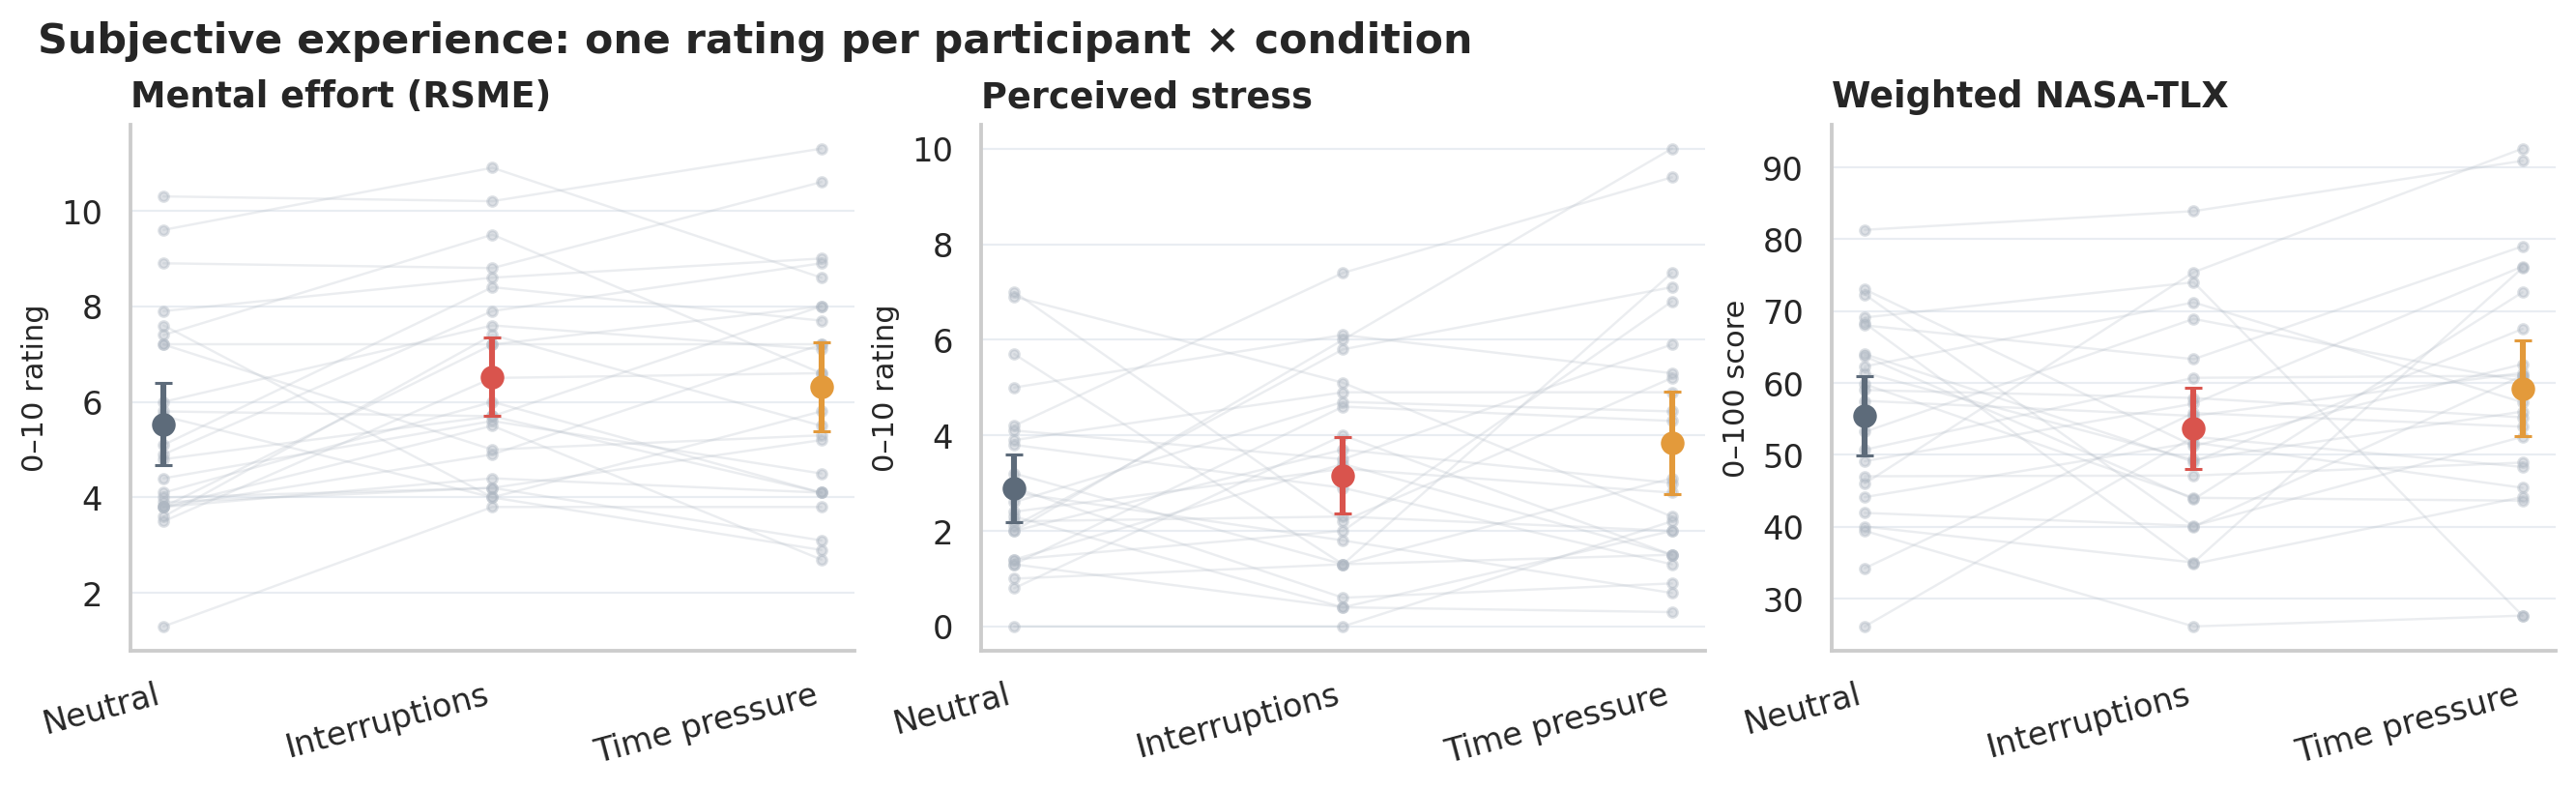

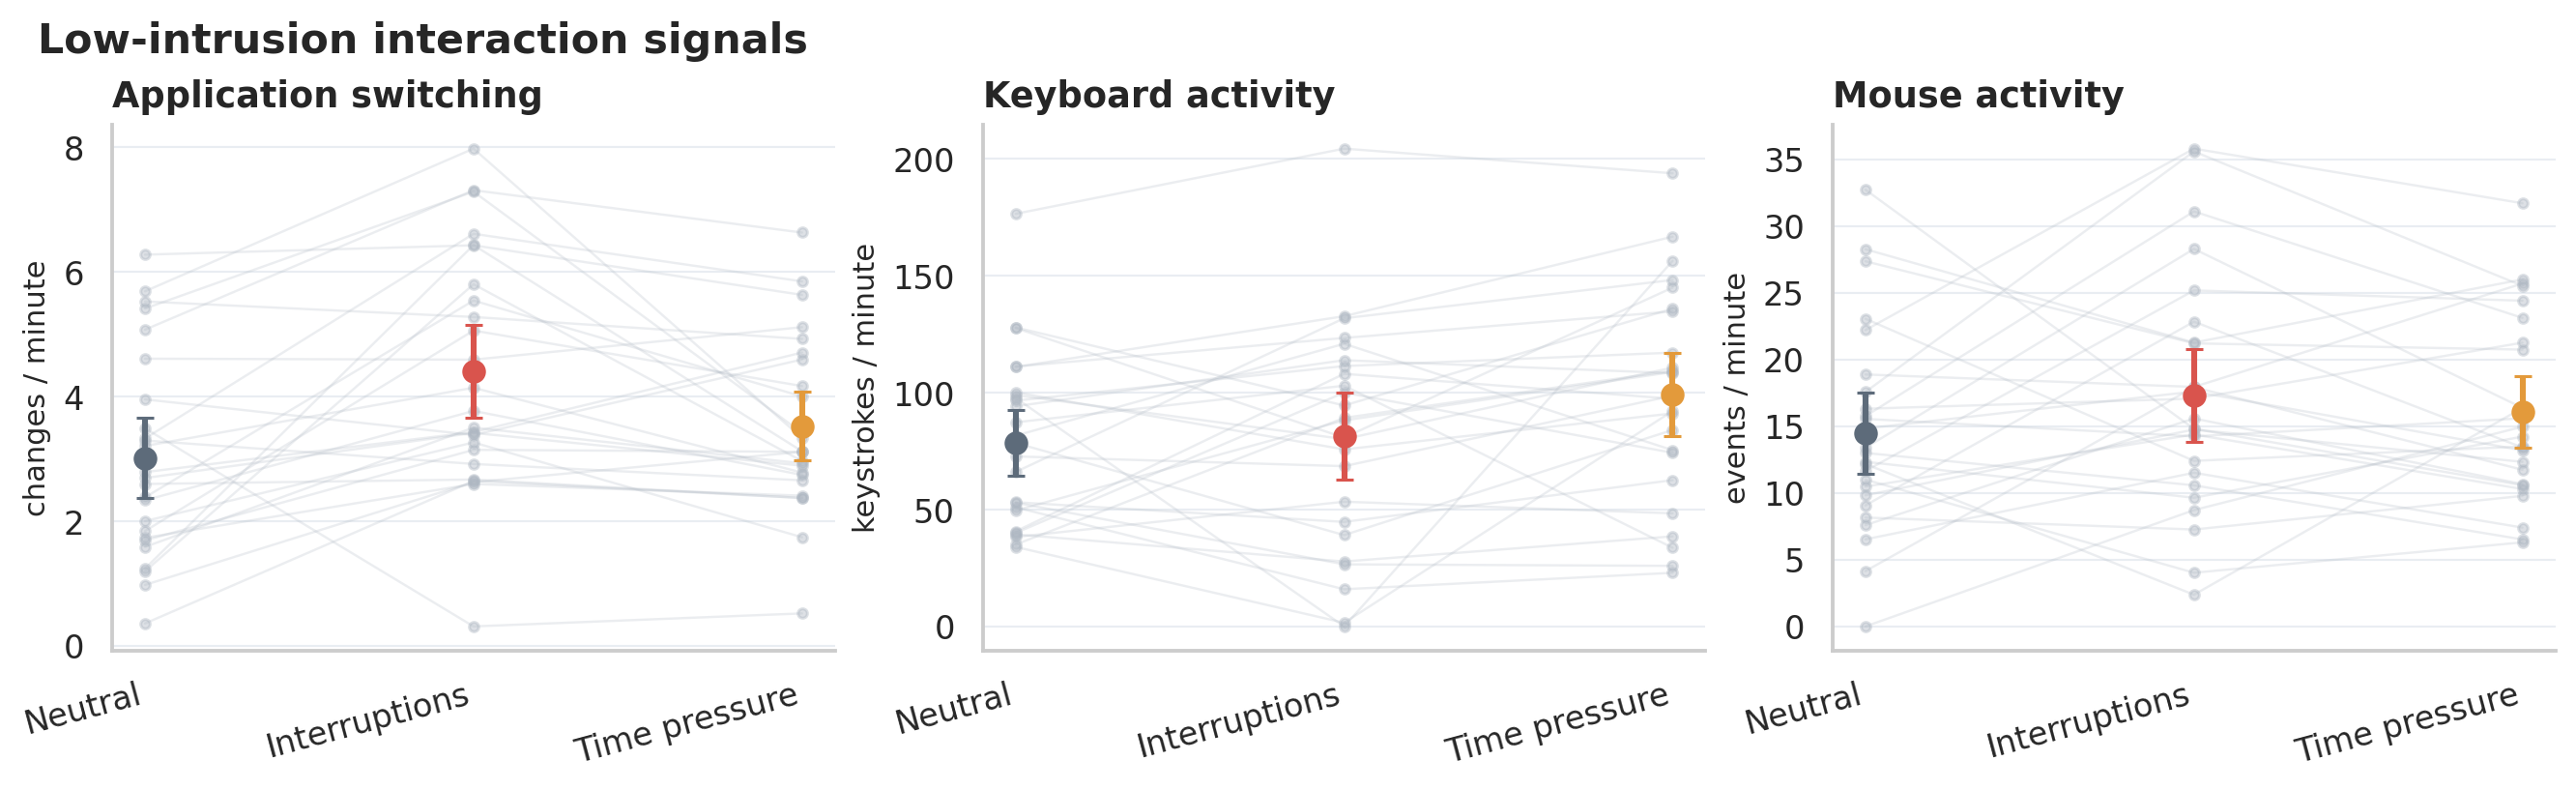

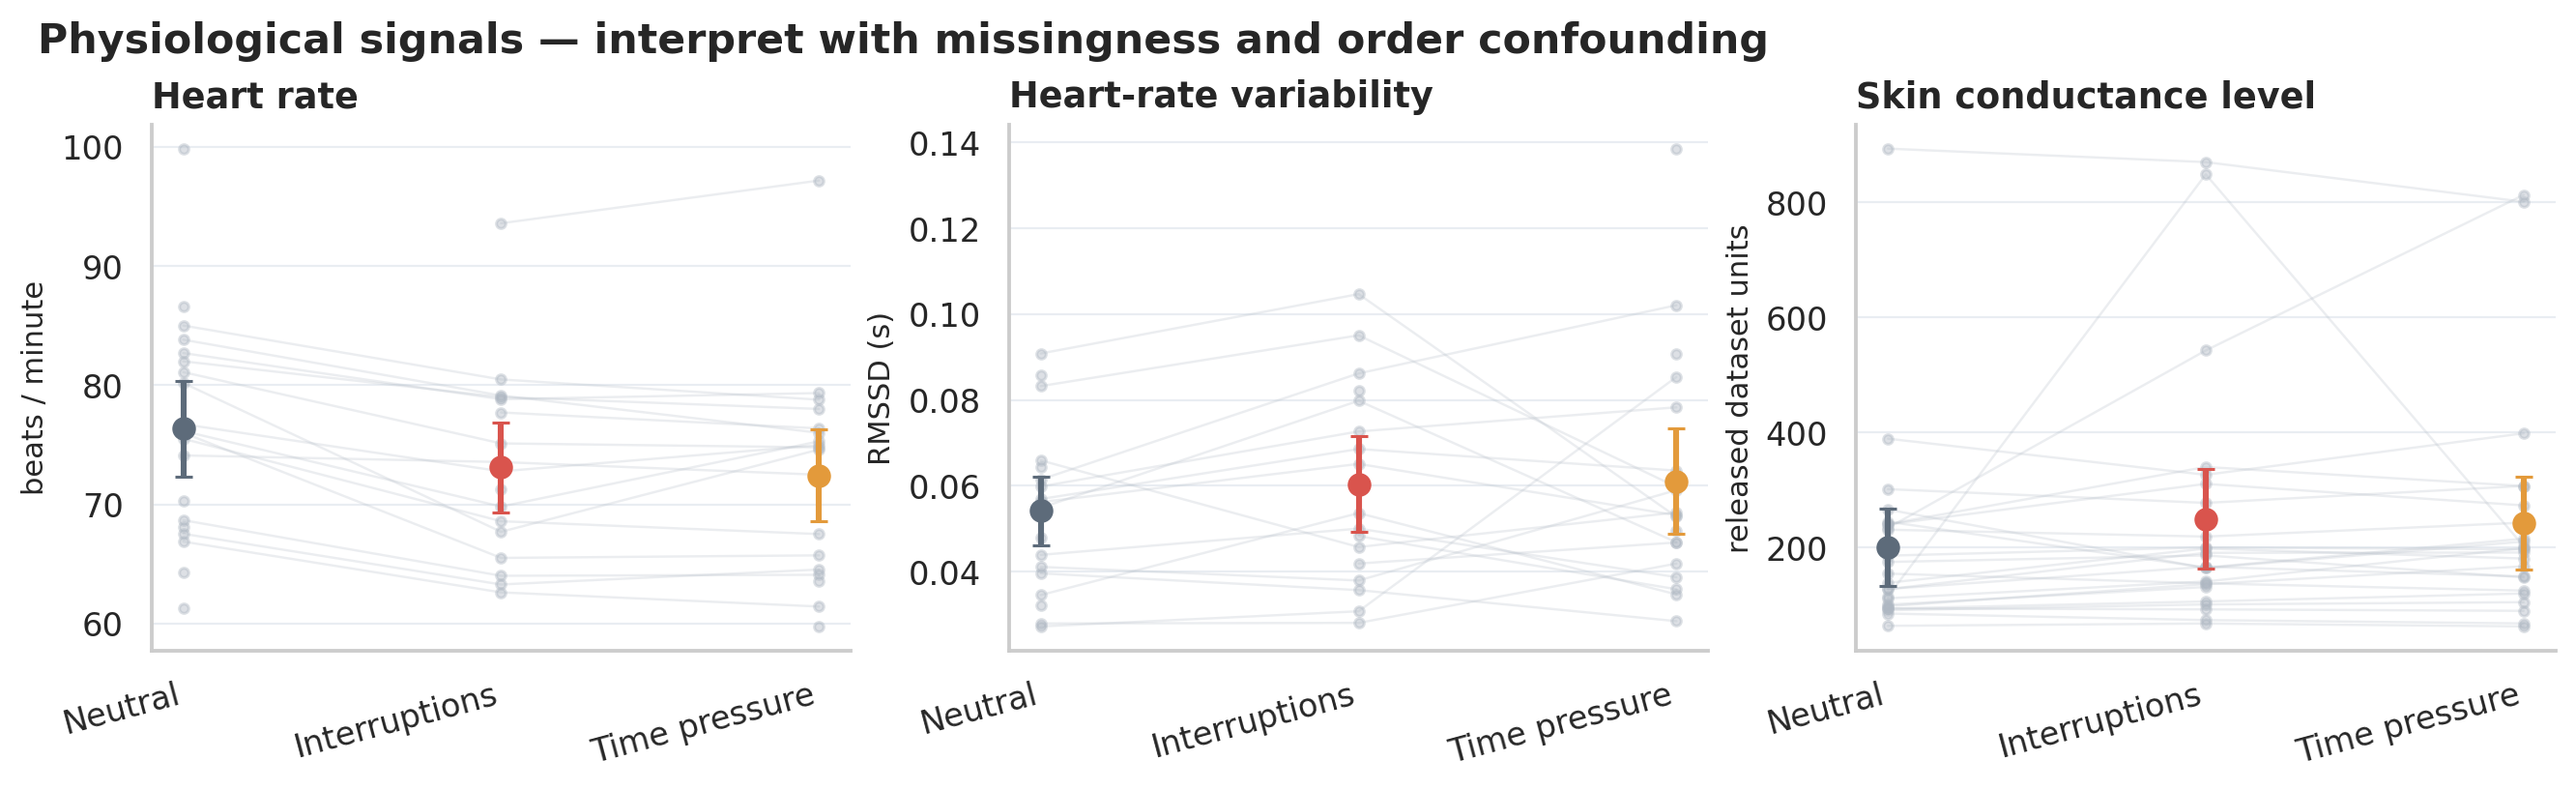

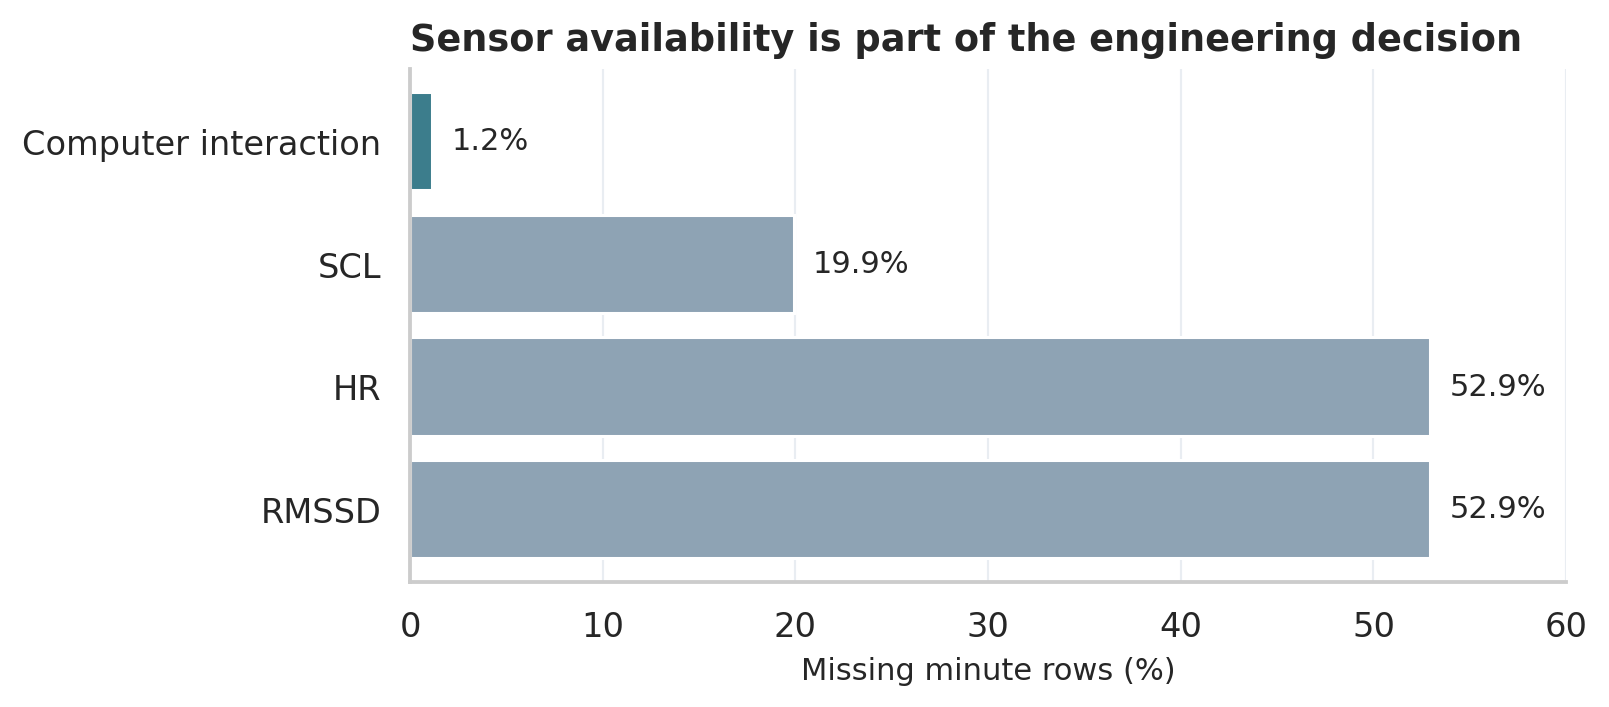

In [4]:
from IPython.display import Image, display
for name in ["subjective_conditions.png", "behavior_conditions.png", "physiology_conditions.png", "sensor_missingness.png"]:
    display(Image(filename=str(ROOT / "figures" / name), width=900))